# Classification: MiniBatch vs K-SVD dictionaries x 5 classifiers
* Protocol: leave-one-repetition-out (rep 6 = test), restimulus labels.
* No data leakage: dictionary and scaler fit on train only.

In [ ]:
%load_ext autoreload
%autoreload 2
 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
 
from utils import (build_features, run_classification,
                   plot_accuracy_comparison, plot_confusion_matrix,
                   plot_sparse_heatmap)

## LOAD

In [ ]:
Y1_tr = np.load('preprocessed_data/Y1_tr.npy')
Y1_te = np.load('preprocessed_data/Y1_te.npy')
y1_tr = np.load('preprocessed_data/y1_tr.npy')
y1_te = np.load('preprocessed_data/y1_te.npy')
 
Y2_tr = np.load('preprocessed_data/Y2_tr.npy')
Y2_te = np.load('preprocessed_data/Y2_te.npy')
y2_tr = np.load('preprocessed_data/y2_tr.npy')
y2_te = np.load('preprocessed_data/y2_te.npy')
 
D1_mb   = np.load('preprocessed_data/D1_mb.npy')
D2_mb   = np.load('preprocessed_data/D2_mb.npy')
D1_ksvd = np.load('preprocessed_data/D1_ksvd.npy')
D2_ksvd = np.load('preprocessed_data/D2_ksvd.npy')
 
SPARSITY = 5
 
print(f"DB1 — train: {Y1_tr.shape[0]} | test: {Y1_te.shape[0]}")
print(f"DB2 — train: {Y2_tr.shape[0]} | test: {Y2_te.shape[0]}")

### Parameters - used in preprocess and k-SVD

In [2]:
WINDOW_MS       = 200
OVERLAP         = 0.5

# DB1
FS_DB1          = 100
CHANNELS_DB1    = 10
SAMPLES_WIN_DB1 = int(WINDOW_MS / 1000 * FS_DB1)   # 100Hz * 0.2s = 20 samples
SPARSITY_DB1    = 5
 
# DB2
FS_DB2          = 2000
CHANNELS_DB2    = 12
SAMPLES_WIN_DB2 = int(WINDOW_MS / 1000 * FS_DB2)   # 2000Hz * 0.2s = 400 samples
SPARSITY_DB2    = 10
 
print(f"DB1 — window vector size: {SAMPLES_WIN_DB1 * CHANNELS_DB1}")
print(f"DB2 — window vector size: {SAMPLES_WIN_DB2 * CHANNELS_DB2}")

DB1 — window vector size: 200
DB2 — window vector size: 4800


### Load preprocessed data

In [3]:
Y_db1 = np.load('preprocessed_data/Y_db1_s1.npy')
D_db1 = np.load('preprocessed_data/D_db1_s1.npy')

Y_db2 = np.load('preprocessed_data/Y_db2_s1.npy')
D_db2 = np.load('preprocessed_data/D_db2_s1.npy')

_, stim1 = load_emg_data('Ninapro_DB1/s1.zip')
_, stim2 = load_emg_data('Ninapro_DB2/DB2_s1.zip')

print(f"\nY_db1: {Y_db1.shape}  |  D_db1: {D_db1.shape}")
print(f"Y_db2: {Y_db2.shape}  |  D_db2: {D_db2.shape}")


Y_db1: (47147, 200)  |  D_db1: (300, 200)
Y_db2: (26192, 4800)  |  D_db2: (400, 4800)


### Visualize Dictionary atoms


--- Dictionary atoms DB1 ---


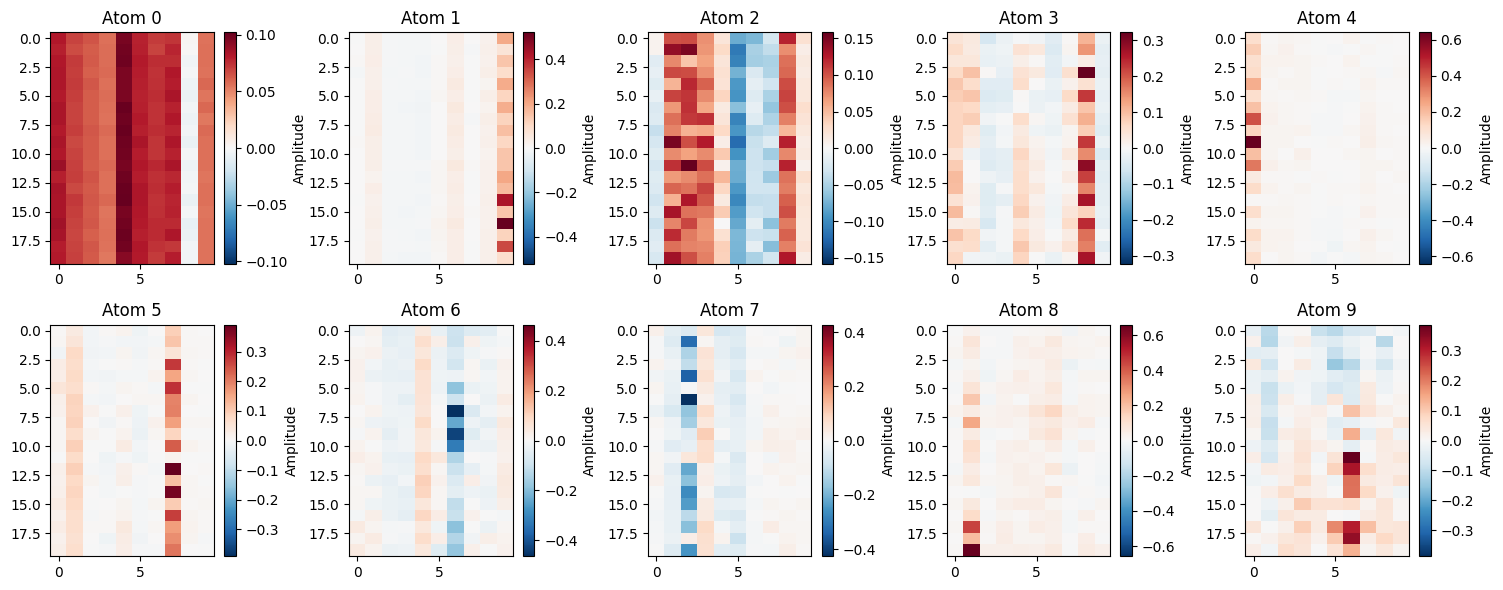

--- Dictionary atoms DB2 ---


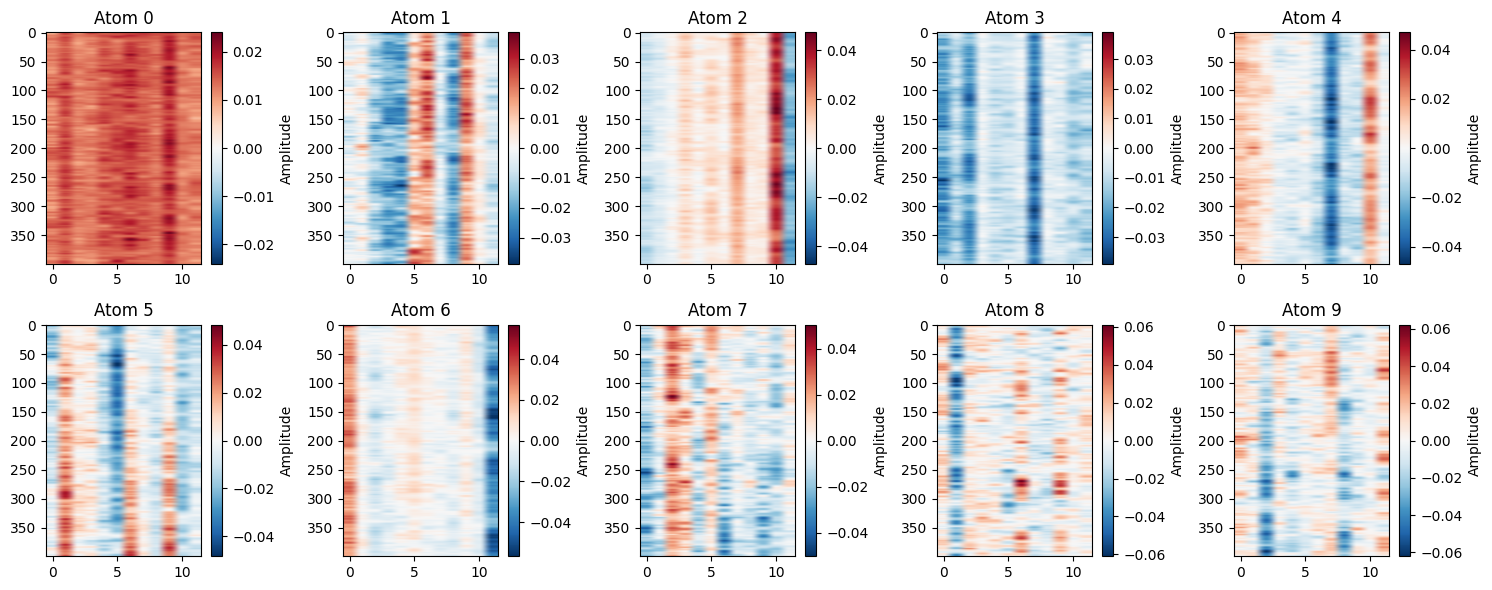

In [4]:
print("\n--- Dictionary atoms DB1 ---")
plot_dictionary_atoms(D_db1, CHANNELS_DB1, SAMPLES_WIN_DB1, n_atoms_to_show=10)
 
print("--- Dictionary atoms DB2 ---")
plot_dictionary_atoms(D_db2, CHANNELS_DB2, SAMPLES_WIN_DB2, n_atoms_to_show=10)

### Feature Extraction

In [5]:
print("\n--- Extracting features DB1 ---")
X1 = build_feature_matrix(Y_db1, D_db1,
                           n_nonzero_coefs=SPARSITY_DB1,
                           n_channels=CHANNELS_DB1,
                           samples_per_window=SAMPLES_WIN_DB1)
print("Done.")

print("\n--- Extracting features DB2 ---")
X2 = build_feature_matrix(Y_db2, D_db2,
                           n_nonzero_coefs=SPARSITY_DB2,
                           n_channels=CHANNELS_DB2,
                           samples_per_window=SAMPLES_WIN_DB2)
print("Done.")


--- Extracting features DB1 ---
Done.

--- Extracting features DB2 ---
Done.


### Label Synchronization

In [6]:
y1 = sync_labels(stim1, fs=FS_DB1, window_ms=WINDOW_MS, overlap=OVERLAP, threshold=0.5)
y2 = sync_labels(stim2, fs=FS_DB2, window_ms=WINDOW_MS, overlap=OVERLAP, threshold=0.5)
 
print(f"\nDB1 — X: {X1.shape}, y: {y1.shape}")
print(f"DB2 — X: {X2.shape}, y: {y2.shape}")
 
# Sanity check: number of windows must match
assert X1.shape[0] == y1.shape[0], (
    f"DB1 window/label mismatch: {X1.shape[0]} windows vs {y1.shape[0]} labels"
)
assert X2.shape[0] == y2.shape[0], (
    f"DB2 window/label mismatch: {X2.shape[0]} windows vs {y2.shape[0]} labels"
)


DB1 — X: (47147, 330), y: (47147,)
DB2 — X: (26192, 436), y: (26192,)


### Visualize Sparse Coefficients Heatmap


--- Heatmap of activation ---


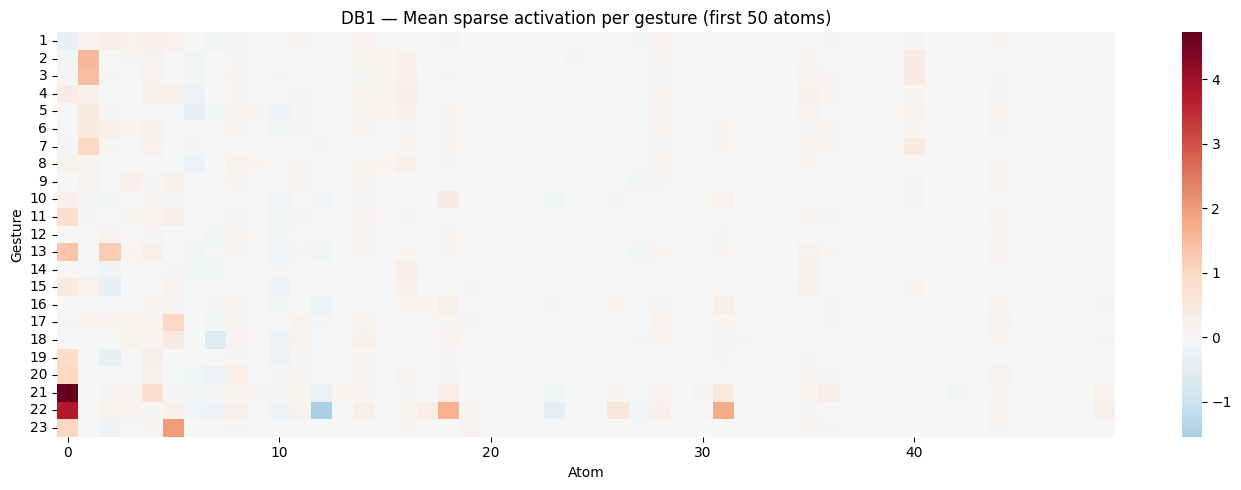

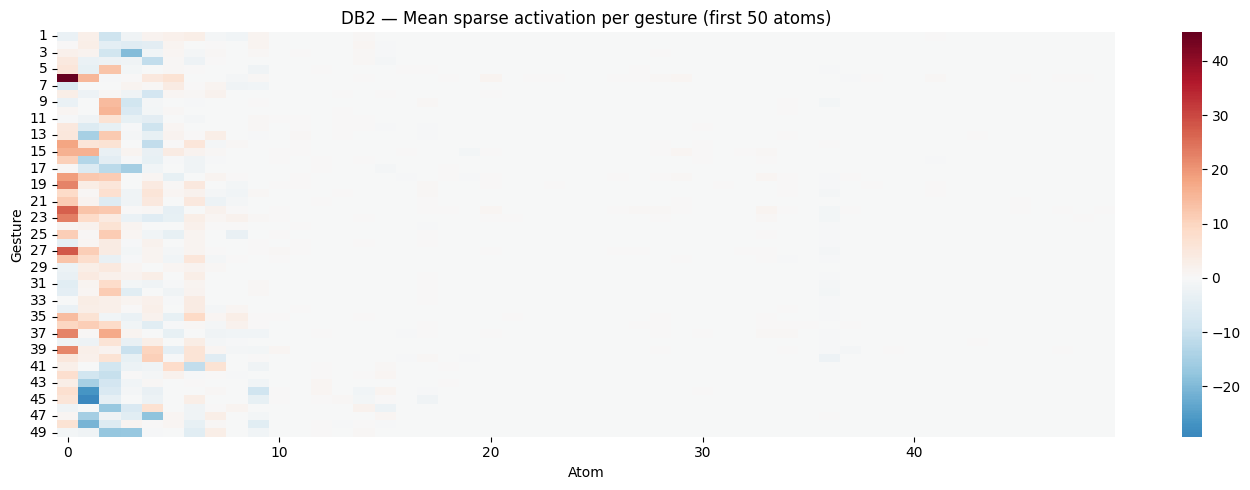

In [7]:
# Extract just sparse part for visualisation (before concatenation with handcrafted)
def plot_mean_activation(Y, D, y, n_nonzero_coefs, n_atoms_show=50, title=""):
    X_sparse = get_sparse_code(Y, D, n_nonzero_coefs)
    df = pd.DataFrame(X_sparse[:, :n_atoms_show])
    df['label'] = y
    active = df[df['label'] > 0].groupby('label').mean()

    plt.figure(figsize=(14, 5))
    sns.heatmap(active, cmap='RdBu_r', center=0, xticklabels=10)
    plt.title(f'{title} — Mean sparse activation per gesture (first {n_atoms_show} atoms)')
    plt.xlabel('Atom')
    plt.ylabel('Gesture')
    plt.tight_layout()
    plt.show()

print("\n--- Heatmap of activation ---")
plot_mean_activation(Y_db1, D_db1, y1, SPARSITY_DB1, title="DB1")
plot_mean_activation(Y_db2, D_db2, y2, SPARSITY_DB2, title="DB2")

### Classification


--- Classification DB1 ---
Acurácia DB1: 57.95%
              precision    recall  f1-score   support

           1       0.58      0.64      0.61       309
           2       0.71      0.54      0.61       309
           3       0.64      0.59      0.61       309
           4       0.54      0.47      0.50       310
           5       0.57      0.59      0.58       309
           6       0.55      0.53      0.54       309
           7       0.53      0.57      0.55       311
           8       0.46      0.59      0.52       311
           9       0.55      0.58      0.57       309
          10       0.55      0.63      0.58       309
          11       0.49      0.41      0.45       311
          12       0.50      0.64      0.56       310
          13       0.66      0.44      0.53       207
          14       0.58      0.67      0.62       207
          15       0.70      0.61      0.65       206
          16       0.62      0.66      0.64       205
          17       0.60      0.5

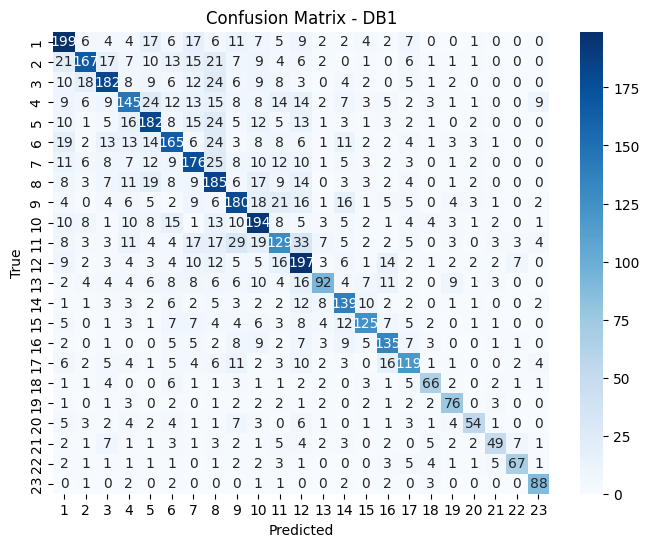


--- Classification DB2 ---


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: Us

Acurácia DB2: 77.73%
              precision    recall  f1-score   support

           1       0.90      0.97      0.94        67
           2       0.70      0.95      0.81        66
           3       0.76      0.76      0.76        66
           4       0.75      0.73      0.74        66
           5       0.86      0.82      0.84        66
           6       0.90      0.79      0.84        67
           7       0.68      0.88      0.77        67
           8       0.53      0.84      0.65        67
           9       0.64      0.73      0.68        66
          10       0.73      0.70      0.71        66
          11       0.77      0.56      0.65        66
          12       0.85      0.49      0.62        67
          13       0.83      0.61      0.70        66
          14       0.83      0.72      0.77        67
          15       0.82      0.95      0.88        66
          16       0.93      0.81      0.86        67
          17       0.80      0.80      0.80        66
      

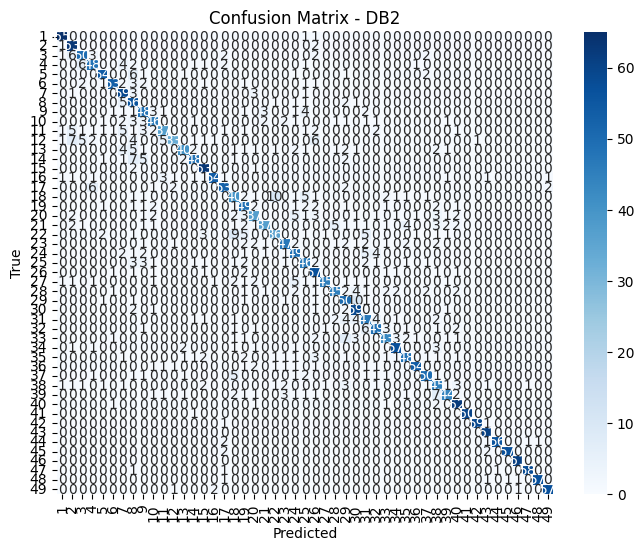

In [8]:
print("\n--- Classification DB1 ---")
clf1, acc1, report1, cm1, labels1 = run_classification(X1, y1, title="DB1")
print(f"Acurácia DB1: {acc1:.2%}")
print(report1)
plot_confusion_matrix(cm1, labels1, title="DB1")

print("\n--- Classification DB2 ---")
clf2, acc2, report2, cm2, labels2 = run_classification(X2, y2, title="DB2")
print(f"Acurácia DB2: {acc2:.2%}")
print(report2)
plot_confusion_matrix(cm2, labels2, title="DB2")

### Final Summary

In [9]:
print("=" * 40)
print("RESUMO")
print("=" * 40)
print(f"DB1  Acurácia: {acc1:.2%}  |  {len(labels1)} classes")
print(f"DB2  Acurácia: {acc2:.2%}  |  {len(labels2)} classes")
print("=" * 40)

RESUMO
DB1  Acurácia: 57.95%  |  23 classes
DB2  Acurácia: 77.73%  |  49 classes
